In [1]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'IMDB' in f or 'imdb' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/IMDB Dataset.csv.zip


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = "/content/drive/MyDrive/IMDB Dataset.csv.zip"
extract_to = "/content/imdb"
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print(os.listdir(extract_to))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['IMDB Dataset.csv']


In [3]:
import pandas as pd
imdb_data = pd.read_csv("/content/imdb/IMDB Dataset.csv")
print(imdb_data.shape)
imdb_data.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# ============================================================
# Import required libraries for data processing, modeling,
# evaluation metrics, statistical tests, and reproducibility
# ============================================================
import os, time, random
import numpy as np
import tensorflow as tf
import pandas as pd
from scipy.stats import ttest_rel
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, Activation,Bidirectional
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorboard.plugins.hparams import api as hp
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar100
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, Add, Input, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import reuters
from tensorflow.keras.utils import to_categorical




# ============================================================
# Dataset Loading and Preprocessing
# ============================================================


In [5]:
# ======================================================================================
# MNIST Dataset Preparation:
# 1. Load the dataset.
# 2. Normalize pixel values to [0, 1]
# 3. Reshape data to (Samples, Height, Width, Channels) for CNN compatibility.
# 4. Convert integer labels to One-Hot encoded vectors
# 5. Split training data to create a Validation set for Early Stopping monitoring.
# ======================================================================================

# Load the dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize pixel
X_train_mnist = X_train_mnist.astype("float32") / 255.0
X_test_mnist  = X_test_mnist.astype("float32") / 255.0

# Reshape
X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist  = X_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encode
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist  = to_categorical(y_test_mnist, 10)

# split

X_train_mnist, X_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    X_train_mnist, y_train_mnist,
    test_size=0.2,
    random_state=42,
    stratify=y_train_mnist
)

# =======  Fashion-MNIST Dataset  ======

In [6]:
# ======================================================================================
# Fashion-MNIST Dataset Preparation:
# 1. Load the dataset
# 2. Normalize pixel values to the range [0, 1]
# 3. Reshape images to include the channel dimension (Height, Width, Channels).
# 4. Perform One-Hot Encoding on labels for multi-class classification.
# ======================================================================================

# Load the dataset
(X_train_fm, y_train_fm), (X_test_fm, y_test_fm) = fashion_mnist.load_data()

# Scale pixel values
X_train_fm = X_train_fm.astype("float32") / 255.0
X_test_fm  = X_test_fm.astype("float32") / 255.0

# Reshape data to (Samples, 28, 28, 1)
X_train_fm = X_train_fm.reshape(-1, 28, 28, 1)
X_test_fm  = X_test_fm.reshape(-1, 28, 28, 1)

# Convert integer class labels to binary class matrices
y_train_fm = to_categorical(y_train_fm, 10)
y_test_fm  = to_categorical(y_test_fm, 10)



# Create a Validation split
X_train_fm, X_val_fm, y_train_fm, y_val_fm = train_test_split(
    X_train_fm, y_train_fm,
    test_size=0.2,
    random_state=42,
    stratify=y_train_fm
)

# =======  CIFAR-100  ======

In [7]:
# =============================
# 3. CIFAR-100
# 1. Load Data
# 2. Split CIFAR-100 Dataset into Train and Val
# 3. Data Augmentation For CIFAR-100 Dataset
# =============================
(X_train_c100, y_train_c100), (X_test_c100, y_test_c100) = cifar100.load_data(label_mode='fine')

X_train_c100 = X_train_c100.astype("float32") / 255.0
X_test_c100  = X_test_c100.astype("float32") / 255.0

y_train_c100 = to_categorical(y_train_c100, 100)
y_test_c100  = to_categorical(y_test_c100, 100)

#=== Split CIFAR-100 Dataset into Train and Val
X_train_c100, X_val_c100, y_train_c100, y_val_c100 = train_test_split(
    X_train_c100, y_train_c100,
    test_size=0.2,
    random_state=42
)

#===Data Augmentation Setup For CIFAR-100 Dataset:
#This helps prevent overfitting and improves the model's ability to generalize to new images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

#Calculates necessary statistics (like mean/std) from the training data to apply feature-wise normalization if required.
datagen.fit(X_train_c100)

# Create a generator for training that delivers transformed images in batches
train_generator_c100 = datagen.flow(
    X_train_c100,
    y_train_c100,
    batch_size=256
)

# =======  IMDB Dataset  ======

In [8]:
# ======================================================================================
# IMDB Dataset Preparation Pipeline:
# 1. Load data and encode labels (Positive: 1, Negative: 0).
# 2. Split the raw data into initial Training and Testing sets.
# 3. Tokenize text data to convert words into numerical sequences .
# 4. Pad sequences to ensure a uniform input length of 200 for the Neural Network.
# 5. Perform a second split to create a Validation set from the training data.
# ======================================================================================

# Load the dataset
imdb_data = pd.read_csv("/content/imdb/IMDB Dataset.csv")

# Encode categorical labels into numerical format
# positive -> 1
# negative -> 0
imdb_data["sentiment"] = imdb_data["sentiment"].map({"positive": 1, "negative": 0})

# First Split: Separate the data into Training and Testing sets (80/20)
train_imdb_data, test_imdb_data = train_test_split(
    imdb_data, test_size=0.2, random_state=42, stratify=imdb_data["sentiment"]
)

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_imdb_data["review"])

# Convert text reviews to numerical sequences and apply padding
x_train_imdb_data = pad_sequences(tokenizer.texts_to_sequences(train_imdb_data["review"]), maxlen=200)
x_test_imdb_data = pad_sequences(tokenizer.texts_to_sequences(test_imdb_data["review"]), maxlen=200)

# Convert labels to NumPy arrays for compatibility with TensorFlow
y_train_imdb_data = train_imdb_data["sentiment"].to_numpy()
y_test_imdb_data = test_imdb_data["sentiment"].to_numpy()

# Second Split: Reserve 20% of the training data for Validation
x_train_imdb_data, x_val_imdb_data, y_train_imdb_data, y_val_imdb_data = train_test_split(
    x_train_imdb_data, y_train_imdb_data,
    test_size=0.2, random_state=42, stratify=y_train_imdb_data
)

In [9]:
# ======================================================================================
# Reuters Newswire Dataset Preparation:
# 1. Load the dataset (Labels are 46 different topics).
# 2. Pad sequences to ensure a uniform length of 200 for Neural Network input.
# 3. Convert labels to One-Hot encoded vectors.
# 4. Split training data to create a Validation set for monitoring training.
# ======================================================================================

from tensorflow.keras.preprocessing import sequence

# Load the dataset
(x_train_reuters, y_train_reuters), (x_test_reuters, y_test_reuters) = reuters.load_data(num_words=10000)

# Pad sequences
max_words = 200
x_train_reuters = sequence.pad_sequences(x_train_reuters, maxlen=max_words)
x_test_reuters = sequence.pad_sequences(x_test_reuters, maxlen=max_words)

# One-hot encode the 46 categorical labels
y_train_reuters = to_categorical(y_train_reuters, 46)
y_test_reuters = to_categorical(y_test_reuters, 46)

# Create a Validation split (20% of training data)
x_train_reuters, x_val_reuters, y_train_reuters, y_val_reuters = train_test_split(
    x_train_reuters, y_train_reuters,
    test_size=0.2,
    random_state=42,
    stratify=y_train_reuters
)

In [10]:
# ============================================================
# List all available built-in activation functions in TensorFlow
# ============================================================

activation_functions = dir(tf.keras.activations)
# Filter out the built-in attributes
activation_functions = [func for func in activation_functions if not func.startswith('__')]
print(activation_functions)

['celu', 'deserialize', 'elu', 'exponential', 'gelu', 'get', 'glu', 'hard_shrink', 'hard_sigmoid', 'hard_silu', 'hard_swish', 'hard_tanh', 'leaky_relu', 'linear', 'log_sigmoid', 'log_softmax', 'mish', 'relu', 'relu6', 'selu', 'serialize', 'sigmoid', 'silu', 'soft_shrink', 'softmax', 'softplus', 'softsign', 'sparse_plus', 'sparse_sigmoid', 'sparsemax', 'squareplus', 'swish', 'tanh', 'tanh_shrink', 'threshold']


# ============================================================
# Definition and registration of custom and baseline activation functions used in the experiments
# ============================================================

In [11]:
# Define the MishRelu activation function

def MishRelU(x):
    return tf.where(x > 0, x, x * tf.keras.activations.tanh(tf.keras.activations.softplus(x)))
get_custom_objects()['MishRelU'] = MishRelU


In [12]:
#Define Baseline ReLU activation function

def ReLU(x):
    return tf.keras.activations.relu(x)
get_custom_objects()['ReLU'] = ReLU


In [13]:
#Define Baseline Mish activation function
def Mish(x):
    return x * tf.keras.activations.tanh(tf.keras.activations.softplus(x))
get_custom_objects()['Mish'] = Mish

In [14]:
#Define Baseline Elu activation function
def Elu(x,a=1):
    return  tf.keras.activations.elu(x, alpha=a)
get_custom_objects()['Elu'] = Elu


In [15]:
#Define  Baseline LeakyReLU activation function
def LeakyReLU(x):
    return tf.keras.layers.LeakyReLU(alpha=0.01)(x)
get_custom_objects()['LeakyReLU'] = LeakyReLU


In [16]:
#Define Baseline Selu activation function
def Selu(x):
    return tf.keras.activations.selu(x)
get_custom_objects()['Selu'] = Selu


In [17]:
import numpy as np
from tensorflow.keras.utils import get_custom_objects

# Scaling factor derived so that left-hand and right-hand
# derivatives at x=0 both equal 1.0 (C1-smoothness fix for MishReLU)
ALPHA_SMISH = 1.0 / np.tanh(np.log(2.0))  # ≈ 1.666667

def SMishReLU(x):
    mish_part = ALPHA_SMISH * x * tf.keras.activations.tanh(
        tf.keras.activations.softplus(x))
    return tf.where(x > 0, x, mish_part)

get_custom_objects()['SMishReLU'] = SMishReLU

In [18]:
# ============================================================
# P-SMishReLU: Adaptive Parametric Extension of SMishReLU
# Introduces a learnable beta parameter that adjusts negative
# curvature while strictly preserving C1-smoothness at x=0
# (softplus(beta*0) = softplus(0) = ln2 regardless of beta,
#  so the derivative match at x=0 always holds).
# ============================================================
from tensorflow.keras.layers import Layer

class PSMishReLU(Layer):
    def __init__(self, init_beta=1.0, **kwargs):
        super(PSMishReLU, self).__init__(**kwargs)
        self.alpha = 1.0 / np.tanh(np.log(2.0))  # ≈ 1.666667
        self.init_beta = init_beta

    def build(self, input_shape):
        self.beta = self.add_weight(
            name='beta',
            shape=(1,),
            initializer=tf.keras.initializers.Constant(self.init_beta),
            trainable=True
        )
        super(PSMishReLU, self).build(input_shape)

    def call(self, x):
        mish_part = self.alpha * x * tf.keras.activations.tanh(
            tf.keras.activations.softplus(self.beta * x))
        return tf.where(x > 0, x, mish_part)

    def get_config(self):
        config = super(PSMishReLU, self).get_config()
        config.update({"init_beta": self.init_beta})
        return config

In [19]:
def FastSMishReLU(x):
    gamma = 2.0
    negative_part = gamma * x * tf.keras.activations.sigmoid(1.702 * x)
    return tf.where(x > 0, x, negative_part)

get_custom_objects()['FastSMishReLU'] = FastSMishReLU

In [20]:
# ======================================================================================
# Reproducibility Function:
# and the operating system environment.
# ======================================================================================
def set_seed(seed=42):
    # Fix the hash seed for consistent dictionary/set behavior
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Fix the seed for Python's built-in random module
    random.seed(seed)

    # Fix the seed for NumPy's numerical operations
    np.random.seed(seed)

    # Fix the seed for TensorFlow/Keras operations (Initializers, Shuffling, etc.)
    tf.random.set_seed(seed)

In [21]:
# ============================================================
# Reproducibility setup
# Random seeds
## This function fixes the random seeds across all libraries (Python, NumPy, TensorFlow)
# By setting a constant seed, we ensure that  every time the code runs, it produces identical results
# ============================================================
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)



# ============================================================
# Multi-Layer Perceptron (MLP) model for Fashion-MNIST
# ============================================================

In [22]:
def build_fashion_model_MLP(activation, optimizer_name='adam', learning_rate=0.001):
    # Sequential model
    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28)))
    model.add(layers.Flatten())

    model.add(layers.Dense(units=398))
    model.add(layers.Activation(activation))
    model.add(BatchNormalization())
    model.add(layers.Dropout(rate=0.1))

    model.add(layers.Dense(units=128))
    model.add(layers.Activation(activation))
    model.add(BatchNormalization())
    model.add(layers.Dropout(rate=0.1))

    model.add(layers.Dense(units=64))
    model.add(layers.Activation(activation))
    model.add(BatchNormalization())
    model.add(layers.Dropout(rate=0.1))

    # Output layer
    model.add(layers.Dense(units=10, activation='softmax'))

    # --------- اختيار الـ Optimizer ---------
    optimizer_name = optimizer_name.lower()

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

# ============================================================
# Convolutional Neural Network (CNN) model for MNIST
# ============================================================

In [23]:
def build_mnist_model_cnn3(activation, optimizer_name='adam', learning_rate=0.001):
    model = Sequential()

    # Input layer
    model.add(Input(shape=(28, 28, 1)))

    def add_act(m):
        # P-SMishReLU is a Layer class (has learnable weights),
        # everything else is a plain function used via layers.Activation
        if activation == "P-SMishReLU":
            m.add(PSMishReLU())
        else:
            m.add(layers.Activation(activation))

    model.add(layers.Conv2D(32, (3,3), padding='same'))
    add_act(model)
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), strides=2))
    model.add(Dropout(0.25))

    model.add(layers.Conv2D(64, (3,3), padding='same'))
    add_act(model)
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), strides=2))
    model.add(Dropout(0.25))

    model.add(layers.Conv2D(128, (3,3), padding='same'))
    add_act(model)
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((2,2), strides=2))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(layers.Dense(512))
    add_act(model)
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(layers.Dense(10, activation='softmax'))

    # --------- Optimizer selection ---------
    optimizer_name = optimizer_name.lower()

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

# ======= ResNet-18 architecture adapted for CIFAR-100 dataset ========


In [24]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input
from tensorflow.keras.models import Model


def resnet_block(x, filters,activation_fc='relu', stride=1):
    shortcut = x

    x = Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation(activation_fc)(x)

    x = Conv2D(filters, 3, strides=1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation(activation_fc)(x)
    return x


In [25]:
def ResNet18_CIFAR(input_shape=(32,32,3), num_classes=100, activation_fc='relu'):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, 3, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation(activation_fc)(x)

    x = resnet_block(x, 64, activation_fc=activation_fc)
    x = resnet_block(x, 64, activation_fc=activation_fc)

    x = resnet_block(x, 128, activation_fc=activation_fc, stride=2)
    x = resnet_block(x, 128, activation_fc=activation_fc)

    x = resnet_block(x, 256, activation_fc=activation_fc, stride=2)
    x = resnet_block(x, 256, activation_fc=activation_fc)

    x = resnet_block(x, 512, activation_fc=activation_fc, stride=2)
    x = resnet_block(x, 512, activation_fc=activation_fc)

    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation=activation_fc)(x)
    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inputs, outputs)

In [26]:
def build_model(
    input_shape=(32,32,3),
    activation_fc='relu',
    learning_rate=0.001,
    num_classes=100):

    model = ResNet18_CIFAR(
        input_shape=input_shape,
        num_classes=num_classes,
        activation_fc=activation_fc
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [27]:
# ======================================================================================
# Early Stopping Callback:
# This mechanism prevents overfitting by monitoring the model's performance on the
# validation set.
# ======================================================================================
from tensorflow.keras.callbacks import EarlyStopping

early_stop_cifar100 = EarlyStopping(
    monitor='val_loss',       # Monitor the validation loss to detect the stagnation point
    patience=5,               # Number of epochs to wait before stopping if no improvement occurs
    restore_best_weights=True # Automatically rollback to the weights that gave the lowest val_loss
)

# ======= LSTM MODEL For IMDB Dataset =======

In [28]:
# LSTM MODEL BUILDING
def build_lstm_model(activation, optimizer_name,learning_rate):
    model = Sequential()
    model.add(Embedding(input_dim =5000, output_dim = 128, input_length = 200))
    model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(32, activation=activation, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    # Use Adam optimizer
    # --------- اختيار الـ Optimizer ---------
    optimizer_name = optimizer_name.lower()

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'adamw':
        optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    elif optimizer_name == 'radam':
        try:
            optimizer = tfa.optimizers.RectifiedAdam(learning_rate=learning_rate)
        except:
            raise ValueError("RAdam requires tensorflow-addons installed.")
    elif optimizer_name == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# BiLSTM MODEL

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Activation
from tensorflow.keras import regularizers


def BiLSTM_model(activation, optimizer_name, learning_rate):
    # بناء النموذج
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=32, input_length=200))
    model.add(Bidirectional(LSTM(32, return_sequences=False)))
    model.add(Dropout(0.5))
    model.add(Dense(32, kernel_regularizer=regularizers.l2(0.001)))
    model.add(Activation(activation))
    model.add(Dropout(0.2))
    model.add(Dense(46, activation='softmax'))  # num_classes=46

    # تحديد المحسن Optimizer
    optimizer_name = optimizer_name.lower()
    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'adamw':
        optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-4)
    elif optimizer_name == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    elif optimizer_name == 'radam':
        try:
            optimizer = tfa.optimizers.RectifiedAdam(learning_rate=learning_rate)
        except:
            raise ValueError("RAdam requires tensorflow-addons installed.")
    elif optimizer_name == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Compile the model
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [30]:
import os
os.makedirs("/content/drive/MyDrive/activation_experiments", exist_ok=True)


# ====================================
# Model training and evaluation
# - Multiple random seeds
# - Different learning rates
# - Mean and standard deviation are reported
# ====================================

In [31]:
import os
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# SETTINGS
# ============================================================

SEEDS = [164, 343, 865, 599, 251]

RESULT_FILE = "/content/drive/MyDrive/activation_experiments/activation_results_progress.csv"

activation_functions = [
    MishRelU, SMishReLU, FastSMishReLU, "P-SMishReLU",
    ReLU, Mish, Elu, LeakyReLU, Selu
]

learning_rates = [0.01, 0.001, 0.0001]
optimizers = ["nadam"]

# ============================================================
# LOAD PREVIOUS PROGRESS
# ============================================================

if os.path.exists(RESULT_FILE):
    df_old = pd.read_csv(RESULT_FILE)
    print(f"Previous progress found! Saved seed results: {len(df_old)}")
else:
    df_old = pd.DataFrame()
    print("No previous progress found. Starting from the beginning.")

def get_completed_seeds(df, activation_name, optimizer_name, learning_rate):
    if df.empty:
        return set()
    required = {"activation", "optimizer", "lr", "seed"}
    if not required.issubset(df.columns):
        return set()
    mask = (
        (df["activation"] == activation_name) &
        (df["optimizer"] == optimizer_name) &
        (df["lr"] == learning_rate)
    )
    return set(df.loc[mask, "seed"].astype(int).tolist())

# ============================================================
# MAIN EXPERIMENT
# ============================================================

for activation in activation_functions:
    act_name = activation if isinstance(activation, str) else activation.__name__

    for optimizer_name in optimizers:
        for learning_rate in learning_rates:

            print(f"\n{'='*70}\nCONFIGURATION: {act_name} | {optimizer_name} | lr={learning_rate}\n{'='*70}")

            completed_seeds = get_completed_seeds(df_old, act_name, optimizer_name, learning_rate)
            remaining_seeds = [s for s in SEEDS if s not in completed_seeds]

            if completed_seeds:
                print(f"Already completed seeds: {sorted(completed_seeds)}")
            if not remaining_seeds:
                print(">>> All seeds already completed. Skipping.")
                continue

            print(f"Seeds remaining: {remaining_seeds}")

            for seed in remaining_seeds:
                print(f"\n--- STARTING SEED {seed} | {act_name} | lr={learning_rate} ---")
                seed_start = time.time()

                try:
                    set_seed(seed)
                    tf.keras.backend.clear_session()
                    gc.collect()

                    model = build_mnist_model_cnn3(
                        activation, optimizer_name=optimizer_name, learning_rate=learning_rate
                    )

                    history = model.fit(
                        X_train_mnist, y_train_mnist,
                        epochs=30, validation_split=0.2, batch_size=60, verbose=0
                    )

                    test_loss, test_acc = model.evaluate(X_test_mnist, y_test_mnist, verbose=0)

                    y_pred_probs = model.predict(X_test_mnist, verbose=0)
                    y_pred = np.argmax(y_pred_probs, axis=1)
                    y_true = np.argmax(y_test_mnist, axis=1)

                    precision = precision_score(y_true, y_pred, average="macro")
                    recall = recall_score(y_true, y_pred, average="macro")
                    f1 = f1_score(y_true, y_pred, average="macro")

                    seed_time = (time.time() - seed_start) / 60

                    seed_result = {
                        "activation": act_name, "optimizer": optimizer_name, "lr": learning_rate,
                        "seed": seed, "test_loss": test_loss, "accuracy": test_acc,
                        "precision": precision, "recall": recall, "f1": f1, "time_minutes": seed_time
                    }

                    if df_old.empty:
                        df_old = pd.DataFrame([seed_result])
                    else:
                        dup_mask = (
                            (df_old["activation"] == act_name) &
                            (df_old["optimizer"] == optimizer_name) &
                            (df_old["lr"] == learning_rate) &
                            (df_old["seed"] == seed)
                        )
                        df_old = df_old[~dup_mask]
                        df_old = pd.concat([df_old, pd.DataFrame([seed_result])], ignore_index=True)

                    df_old.to_csv(RESULT_FILE, index=False)

                    print(f"✓ Seed {seed} done | Acc: {test_acc:.4f} | Time: {seed_time:.2f} min")

                    del model, history, y_pred_probs, y_pred, y_true
                    gc.collect()
                    tf.keras.backend.clear_session()

                except Exception as e:
                    print(f"❌ ERROR at seed {seed}: {e}")
                    try:
                        del model
                    except:
                        pass
                    gc.collect()
                    tf.keras.backend.clear_session()
                    break

# ============================================================
# FINAL SUMMARY
# ============================================================

if os.path.exists(RESULT_FILE):
    df_seed_results = pd.read_csv(RESULT_FILE)
    print(f"\nTotal completed seed runs: {len(df_seed_results)}")

    df_summary = (
        df_seed_results
        .groupby(["activation", "optimizer", "lr"])
        .agg(
            mean_acc=("accuracy", "mean"), std_acc=("accuracy", "std"),
            mean_prec=("precision", "mean"), std_prec=("precision", "std"),
            mean_rec=("recall", "mean"), std_rec=("recall", "std"),
            mean_f1=("f1", "mean"), std_f1=("f1", "std"),
            completed_seeds=("seed", "count"),
            total_time_minutes=("time_minutes", "sum")
        )
        .reset_index()
    )

    SUMMARY_FILE = "/content/drive/MyDrive/activation_experiments/activation_results_summary.csv"
    df_summary.to_csv(SUMMARY_FILE, index=False)

    print("\n=== CONFIGURATION SUMMARY ===")
    print(df_summary)
else:
    print("No results generated yet.")

Previous progress found! Saved seed results: 130

CONFIGURATION: MishRelU | nadam | lr=0.01
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already completed. Skipping.

CONFIGURATION: MishRelU | nadam | lr=0.001
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already completed. Skipping.

CONFIGURATION: MishRelU | nadam | lr=0.0001
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already completed. Skipping.

CONFIGURATION: SMishReLU | nadam | lr=0.01
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already completed. Skipping.

CONFIGURATION: SMishReLU | nadam | lr=0.001
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already completed. Skipping.

CONFIGURATION: SMishReLU | nadam | lr=0.0001
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already completed. Skipping.

CONFIGURATION: FastSMishReLU | nadam | lr=0.01
Already completed seeds: [164, 251, 343, 599, 865]
>>> All seeds already


# ============================================================
# Statistical significance analysis
# Friedman test followed by post-hoc Wilcoxon test
# ============================================================

In [33]:
activations = ["MishRelU", "SMishReLU", "FastSMishReLU", "P-SMishReLU", "ReLU", "Mish", "Elu", "LeakyReLU", "Selu"]
learning_rates = [0.01, 0.001, 0.0001]

metrics = ["mean_acc", "mean_prec", "mean_rec", "mean_f1"]

friedman_results = []

for lr in learning_rates:
    print(f"\n=== Friedman Test for lr = {lr} ===")
    for metric in metrics:
        #
        values = [df_summary.query(f"activation=='{act}' and lr=={lr}")[metric].values[0] for act in activations]
        stat, p = friedmanchisquare(*values)
        print(f"{metric.replace('mean_', '').capitalize()} -> Friedman statistic = {stat:.4f}, p-value = {p:.6f}")

        friedman_results.append({
            "lr": lr,
            "metric": metric.replace("mean_", "").capitalize(),
            "friedman_statistic": stat,
            "p_value": p
        })

df_friedman = pd.DataFrame(friedman_results)
df_friedman.to_csv("/content/drive/MyDrive/activation_experiments/friedman_test_results.csv", index=False)
print("\nSaved Friedman results to: /content/drive/MyDrive/activation_experiments/friedman_test_results.csv")


=== Friedman Test for lr = 0.01 ===
Acc -> Friedman statistic = 8.0000, p-value = 0.433470
Prec -> Friedman statistic = 8.0000, p-value = 0.433470
Rec -> Friedman statistic = 8.0000, p-value = 0.433470
F1 -> Friedman statistic = 8.0000, p-value = 0.433470

=== Friedman Test for lr = 0.001 ===
Acc -> Friedman statistic = 8.0000, p-value = 0.433470
Prec -> Friedman statistic = 8.0000, p-value = 0.433470
Rec -> Friedman statistic = 8.0000, p-value = 0.433470
F1 -> Friedman statistic = 8.0000, p-value = 0.433470

=== Friedman Test for lr = 0.0001 ===
Acc -> Friedman statistic = 8.0000, p-value = 0.433470
Prec -> Friedman statistic = 8.0000, p-value = 0.433470
Rec -> Friedman statistic = 8.0000, p-value = 0.433470
F1 -> Friedman statistic = 8.0000, p-value = 0.433470

Saved Friedman results to: /content/drive/MyDrive/activation_experiments/friedman_test_results.csv


In [35]:
  import psutil
  print(f"RAM used: {psutil.virtual_memory().percent}%")

RAM used: 36.2%


#========== Post-hoc Wilcoxon Test =============

In [38]:
activations = ["MishRelU", "SMishReLU", "FastSMishReLU", "P-SMishReLU", "ReLU", "Mish", "Elu", "LeakyReLU", "Selu"]
metrics = ["mean_acc", "mean_prec", "mean_rec", "mean_f1"]
lr = 0.0001

def get_values(act, metric):
    return df_summary.query(f"activation=='{act}' and lr=={lr}")[metric].values[0]

wilcoxon_results = []
avg_score_results = []

for metric in metrics:
    print("\n===================================")
    print("Post-hoc Wilcoxon Test | Metric:", metric.replace("mean_","").upper())
    print("===================================\n")

    # Collect the performance values for each activation function
    data = {act: get_values(act, metric) for act in activations}

    # Compute the mean performance to rank activation functions
    avg_scores = {act: np.mean(vals) for act, vals in data.items()}

    print("Average Scores:")
    for act, score in avg_scores.items():
        print(f"{act}: {score:.4f}")
        avg_score_results.append({
            "metric": metric.replace("mean_", "").upper(),
            "activation": act,
            "mean_score": score
        })

    # the best function
    best_act = max(avg_scores, key=avg_scores.get)
    print(f"\n==> BEST activation (based on mean): {best_act}\n")

    # Wilcoxon between each pair
    print("Wilcoxon Pairwise p-values:")
    for i in range(len(activations)):
        for j in range(i+1, len(activations)):
            act1 = activations[i]
            act2 = activations[j]
            stat, p = wilcoxon(data[act1], data[act2])
            print(f"{act1} vs {act2}: p = {p:.6f}")

            wilcoxon_results.append({
                "metric": metric.replace("mean_", "").upper(),
                "activation_1": act1,
                "activation_2": act2,
                "statistic": stat,
                "p_value": p,
                "best_activation": best_act
            })

df_wilcoxon = pd.DataFrame(wilcoxon_results)
df_avg_scores = pd.DataFrame(avg_score_results)

df_wilcoxon.to_csv("/content/drive/MyDrive/activation_experiments/wilcoxon_posthoc_results.csv", index=False)
df_avg_scores.to_csv("/content/drive/MyDrive/activation_experiments/wilcoxon_avg_scores.csv", index=False)

print("\nSaved Wilcoxon pairwise results to: /content/drive/MyDrive/activation_experiments/wilcoxon_posthoc_results.csv")
print("Saved average scores to: /content/drive/MyDrive/activation_experiments/wilcoxon_avg_scores.csv")


Post-hoc Wilcoxon Test | Metric: ACC

Average Scores:
MishRelU: 0.9944
SMishReLU: 0.9942
FastSMishReLU: 0.9940
P-SMishReLU: 0.9941
ReLU: 0.9942
Mish: 0.9941
Elu: 0.9943
LeakyReLU: 0.9945
Selu: 0.9938

==> BEST activation (based on mean): LeakyReLU

Wilcoxon Pairwise p-values:
MishRelU vs SMishReLU: p = 1.000000
MishRelU vs FastSMishReLU: p = 1.000000
MishRelU vs P-SMishReLU: p = 1.000000
MishRelU vs ReLU: p = 1.000000
MishRelU vs Mish: p = 1.000000
MishRelU vs Elu: p = 1.000000
MishRelU vs LeakyReLU: p = 1.000000
MishRelU vs Selu: p = 1.000000
SMishReLU vs FastSMishReLU: p = 1.000000
SMishReLU vs P-SMishReLU: p = 1.000000
SMishReLU vs ReLU: p = 1.000000
SMishReLU vs Mish: p = 1.000000
SMishReLU vs Elu: p = 1.000000
SMishReLU vs LeakyReLU: p = 1.000000
SMishReLU vs Selu: p = 1.000000
FastSMishReLU vs P-SMishReLU: p = 1.000000
FastSMishReLU vs ReLU: p = 1.000000
FastSMishReLU vs Mish: p = 1.000000
FastSMishReLU vs Elu: p = 1.000000
FastSMishReLU vs LeakyReLU: p = 1.000000
FastSMishReLU 

Saved plot to: /content/drive/MyDrive/activation_experiments/mishrelu_vs_all_derivatives.png


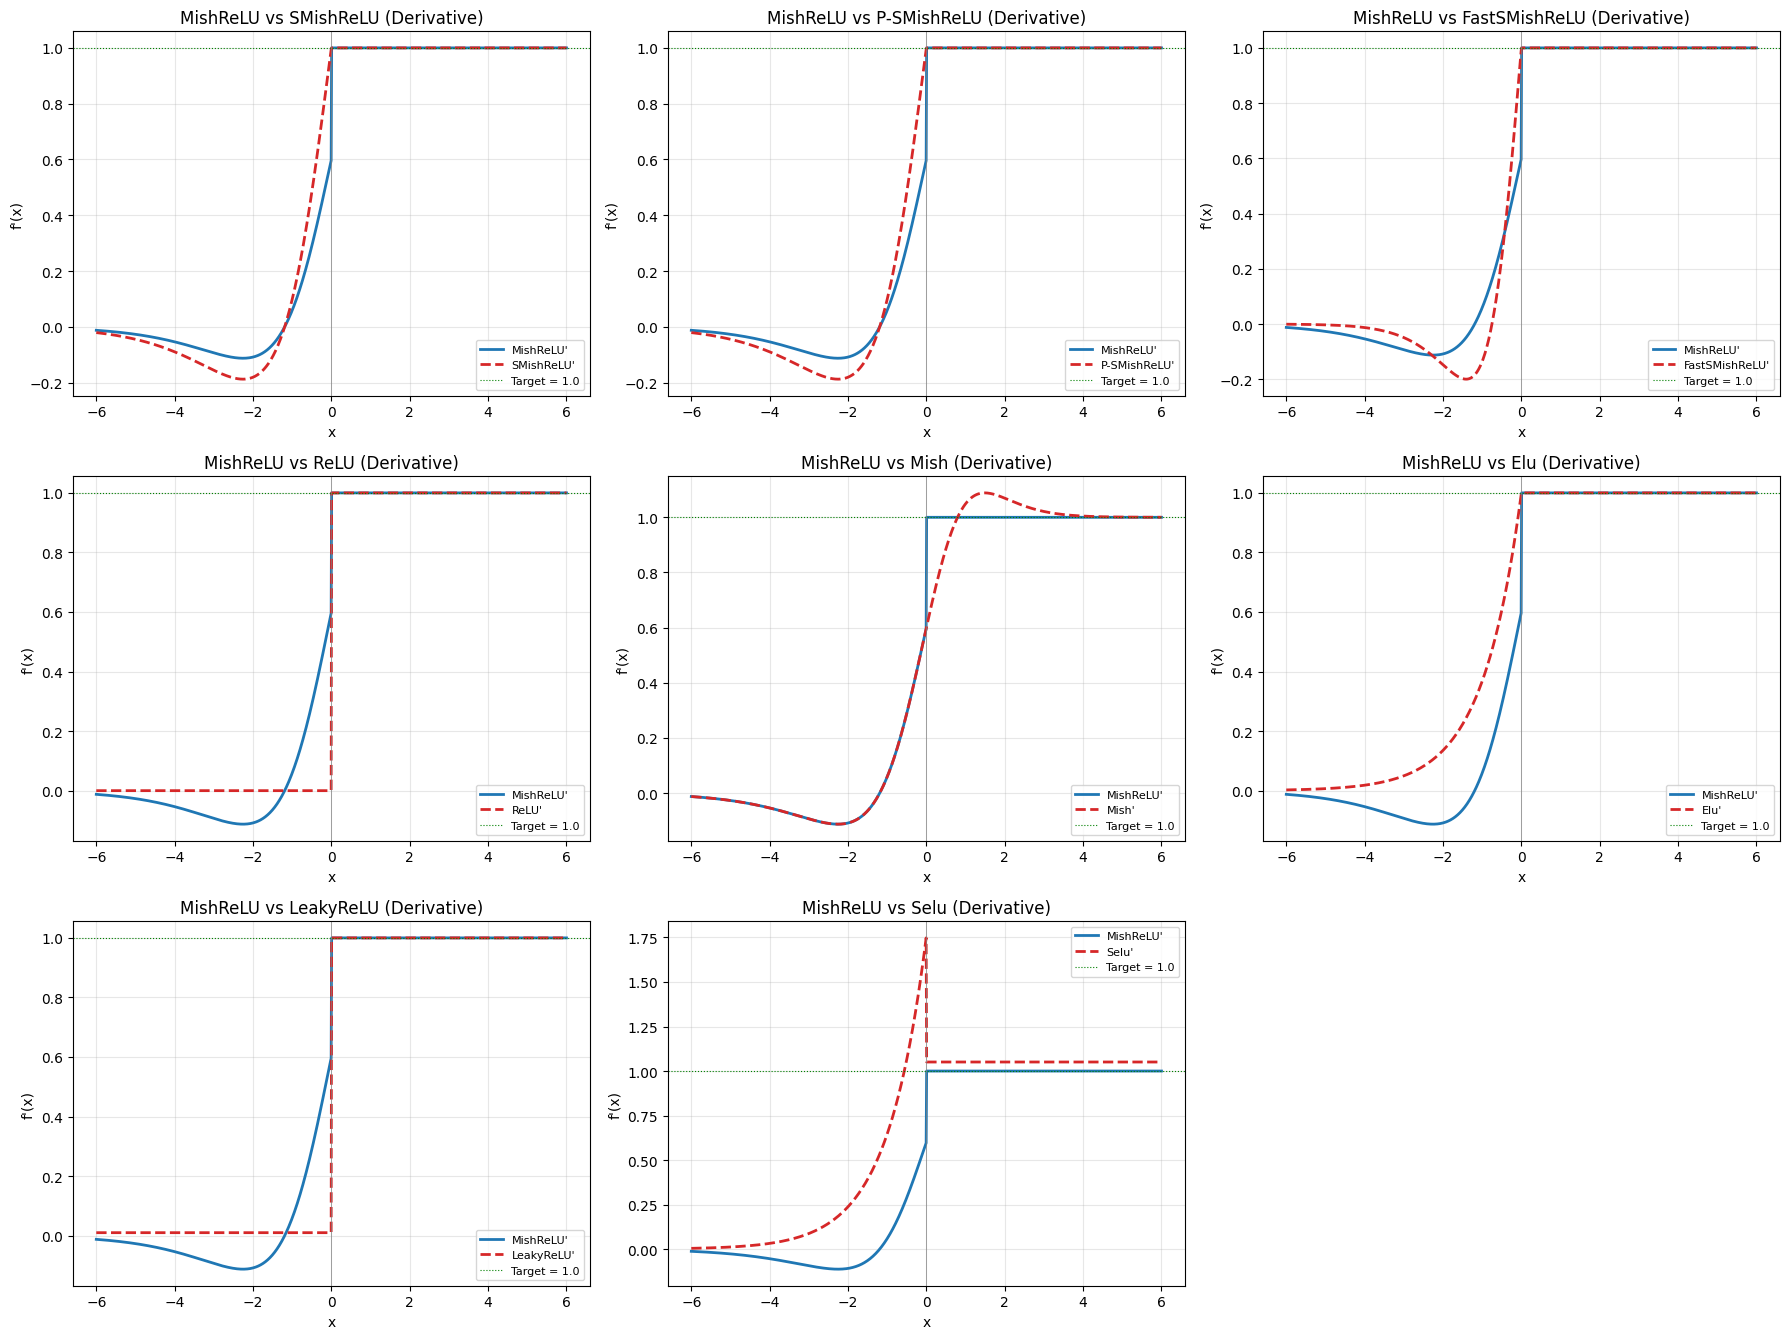

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Numpy versions of all activation functions (for plotting)
# ============================================================
def mishrelu_np(x):
    softplus = np.log1p(np.exp(x))
    return np.where(x > 0, x, x * np.tanh(softplus))

def smishrelu_np(x):
    alpha = 1.0 / np.tanh(np.log(2.0))  # ≈ 1.6667
    softplus = np.log1p(np.exp(x))
    return np.where(x > 0, x, alpha * x * np.tanh(softplus))

def psmishrelu_np(x, beta=1.0):
    alpha = 1.0 / np.tanh(np.log(2.0))  # ≈ 1.6667
    softplus = np.log1p(np.exp(beta * x))
    return np.where(x > 0, x, alpha * x * np.tanh(softplus))

def fastsmishrelu_np(x):
    gamma = 2.0
    sigmoid = 1.0 / (1.0 + np.exp(-1.702 * x))
    return np.where(x > 0, x, gamma * x * sigmoid)

def relu_np(x):
    return np.maximum(0, x)

def mish_np(x):
    softplus = np.log1p(np.exp(x))
    return x * np.tanh(softplus)

def elu_np(x, a=1.0):
    return np.where(x > 0, x, a * (np.exp(x) - 1))

def leakyrelu_np(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def selu_np(x):
    alpha = 1.6732632423543772
    scale = 1.0507009873554805
    return scale * np.where(x > 0, x, alpha * (np.exp(x) - 1))

# Numerical derivative (central difference)
def derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

x = np.linspace(-6, 6, 1000)

# All activations to compare against MishReLU
activations = {
    "SMishReLU": smishrelu_np,
    "P-SMishReLU": psmishrelu_np,
    "FastSMishReLU": fastsmishrelu_np,
    "ReLU": relu_np,
    "Mish": mish_np,
    "Elu": elu_np,
    "LeakyReLU": leakyrelu_np,
    "Selu": selu_np,
}

dy_mishrelu = derivative(mishrelu_np, x)

# ============================================================
# Plot: one subplot per activation, comparing its derivative
# against MishReLU's derivative
# ============================================================
n = len(activations)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
axes = axes.flatten()

for i, (name, func) in enumerate(activations.items()):
    dy = derivative(func, x)

    axes[i].plot(x, dy_mishrelu, label="MishReLU'", color="tab:blue", linewidth=2)
    axes[i].plot(x, dy, label=f"{name}'", color="tab:red", linewidth=2, linestyle="--")
    axes[i].axhline(1.0, color="green", linewidth=0.8, linestyle=":", label="Target = 1.0")
    axes[i].axvline(0, color="gray", linewidth=0.5)
    axes[i].set_title(f"MishReLU vs {name} (Derivative)")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("f'(x)")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide any unused subplots
for j in range(len(activations), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/activation_experiments/mishrelu_vs_all_derivatives.png", dpi=300, bbox_inches="tight")
print("Saved plot to: /content/drive/MyDrive/activation_experiments/mishrelu_vs_all_derivatives.png")

plt.show()

FastSMishReLU   | lr=0.001 | Train: 0.9950 | Val: 0.9925 | Test: 0.9948 | Train-Val gap: 0.0025
                | Verdict: No significant overfitting or underfitting
MishRelU        | lr=0.001 | Train: 0.9951 | Val: 0.9930 | Test: 0.9945 | Train-Val gap: 0.0020
                | Verdict: No significant overfitting or underfitting

Saved overfitting/underfitting check results to: /content/drive/MyDrive/activation_experiments/overfitting_check_results.csv
Saved plot to: /content/drive/MyDrive/activation_experiments/fastsmishrelu_overfitting_check.png


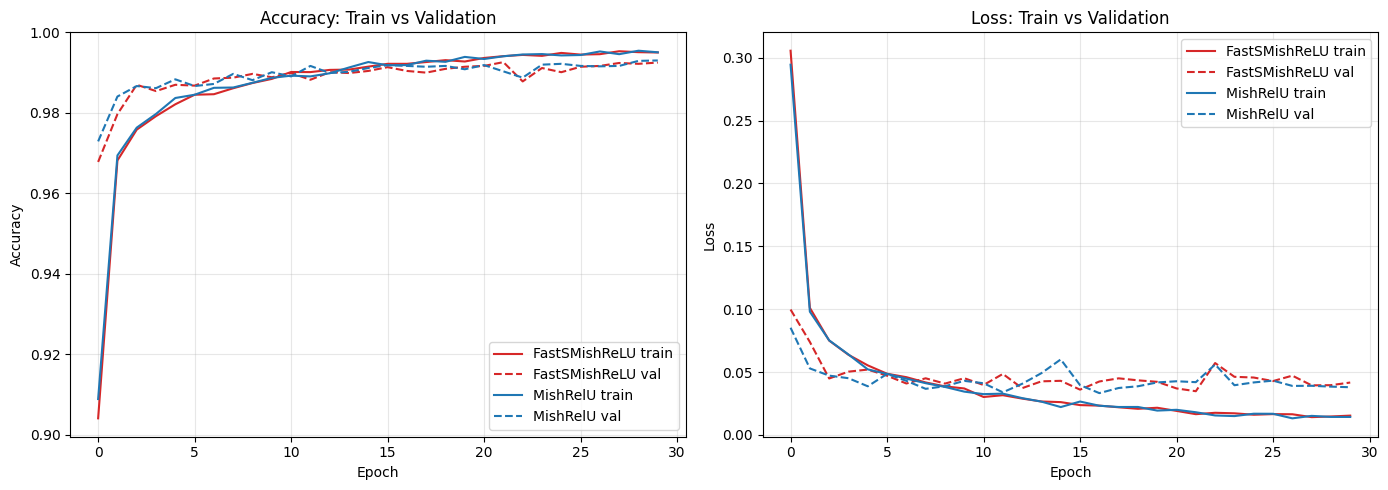

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

def check_overfitting(activation, lr=0.001, seed=164, epochs=30):
    set_seed(seed)
    model = build_mnist_model_cnn3(activation, optimizer_name="nadam", learning_rate=lr)
    history = model.fit(
        X_train_mnist, y_train_mnist,
        epochs=epochs, validation_split=0.2,
        batch_size=60, verbose=0
    )
    h = history.history
    test_loss, test_acc = model.evaluate(X_test_mnist, y_test_mnist, verbose=0)

    train_acc = h['accuracy'][-1]
    val_acc = h['val_accuracy'][-1]
    train_loss_final = h['loss'][-1]
    val_loss_final = h['val_loss'][-1]
    gap = train_acc - val_acc

    print(f"{activation.__name__:15s} | lr={lr} | Train: {train_acc:.4f} | "
          f"Val: {val_acc:.4f} | Test: {test_acc:.4f} | "
          f"Train-Val gap: {gap:.4f}")

    # ============================================================
    # Verdict logic — checks both overfitting AND underfitting
    # ============================================================
    verdict_notes = []

    # 1. Overfitting: train much better than val
    if gap > 0.03:
        verdict_notes.append("Overfitting (train-val accuracy gap > 3%)")

    # 2. Underfitting: model hasn't learned enough — both train and val
    #    accuracy are low (well below the ~99% ceiling expected on MNIST)
    if train_acc < 0.97 and val_acc < 0.97:
        verdict_notes.append("Underfitting (both train & val accuracy low, model not learning enough)")

    # 3. Underfitting via loss: training loss still high/not converged
    if train_loss_final > 0.15:
        verdict_notes.append("Possible underfitting (training loss did not converge low enough)")

    # 4. Val notably better than train (unusual, can indicate
    #    high regularization/dropout causing underfitting on train side)
    if val_acc > train_acc + 0.02:
        verdict_notes.append("Possible underfitting (val accuracy higher than train, regularization may be too strong)")

    if not verdict_notes:
        verdict = "No significant overfitting or underfitting"
    else:
        verdict = " | ".join(verdict_notes)

    print(f"{'':15s} | Verdict: {verdict}")

    return h, {
        "activation": activation.__name__,
        "lr": lr,
        "seed": seed,
        "epochs": epochs,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "test_accuracy": test_acc,
        "train_val_gap": gap,
        "train_loss": train_loss_final,
        "val_loss": val_loss_final,
        "test_loss": test_loss,
        "verdict": verdict
    }

# FastSMishReLU (ours) vs MishRelU (baseline)
histories = {}
summary_rows = []
for act in [FastSMishReLU, MishRelU]:
    h, row = check_overfitting(act, lr=0.001)
    histories[act.__name__] = h
    summary_rows.append(row)

# Save summary to CSV
df_overfit = pd.DataFrame(summary_rows)
CSV_PATH = "/content/drive/MyDrive/activation_experiments/overfitting_check_results.csv"
df_overfit.to_csv(CSV_PATH, index=False)
print(f"\nSaved overfitting/underfitting check results to: {CSV_PATH}")

# Train vs validation curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"FastSMishReLU": "tab:red", "MishRelU": "tab:blue"}
for name, h in histories.items():
    axes[0].plot(h['accuracy'], color=colors[name], label=f"{name} train")
    axes[0].plot(h['val_accuracy'], color=colors[name], linestyle="--", label=f"{name} val")
    axes[1].plot(h['loss'], color=colors[name], label=f"{name} train")
    axes[1].plot(h['val_loss'], color=colors[name], linestyle="--", label=f"{name} val")

axes[0].set_title("Accuracy: Train vs Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Loss: Train vs Validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/activation_experiments/fastsmishrelu_overfitting_check.png", dpi=300, bbox_inches="tight")
print("Saved plot to: /content/drive/MyDrive/activation_experiments/fastsmishrelu_overfitting_check.png")

plt.show()